In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
from sklearn.metrics import roc_curve, auc

!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9
print(len(pmt_positions))

127


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0 600.0k      0                              0
100 303.3k 100 303.3k   0      0 599.5k      0                              0
100 303.3k 100 303.3k   0      0 599.2k      0                              0


: 

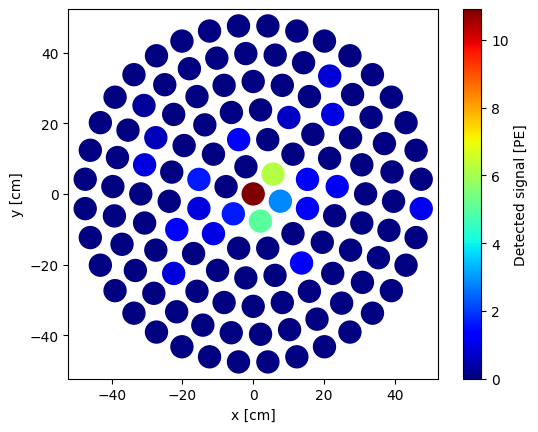

In [3]:
#the same code with more elaborate comments, generated by Claude

def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    
    # Empirical model parameters (fitted to detector calibration data)
    a = -2.7e-5  # Linear attenuation coefficient [1/cm]
    b = 3.6e-3   # Baseline/isotropic light fraction
    i0 = 0.290   # Peak light collection efficiency at rho=0
    d = 12.13    # Characteristic length scale [cm] (half-max radius)
    p = 2.35     # Power law falloff exponent

    # Compute distance from each source position to each PMT
    # xy:            (positions, 2)  -- broadcast to --> (positions, 1,    2)
    # pmt_positions: (pmts,      2)  -- broadcast to --> (1,         pmts, 2)
    # rho:           (positions, pmts) -- one distance per (position, pmt) pair
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)

    # Evaluate the light collection efficiency (LCE) model:
    #   - Lorentzian-like term: bright near centre, falls off with distance
    #   - Linear term: small additional attenuation over distance
    #   - Baseline term b: minimum isotropic response
    raw_lce = i0 * (1 - b) / (1 + (rho / d) ** 2) ** p + a * rho + b

    # Normalize each position's LCE across all PMTs so that the
    # total light collected sums to 1 (conserves photon count)
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]


def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""

    # Get the fractional light yield expected at each PMT for the given position(s)
    # Shape: (positions, pmts)
    lce = mean_response(xy)

    # --- Stage 1: Poisson fluctuations in photon detection ---
    # Each PMT detects photons independently; the expected count is
    # (total photons) * (fractional LCE for that PMT)
    photons_detected = np.random.poisson(photons * lce)

    # --- Stage 2: Double photoelectron (DPE) emission ---
    # Each detected photon has a 20% chance of producing 2 photoelectrons
    # instead of 1; model the extra PEs as a Binomial draw
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)

    # --- Stage 3: Gaussian smearing of the PMT readout ---
    # Electronic noise scales as 0.3 * sqrt(PE), i.e. sub-Poissonian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))


def plot_signal(signal):
    """Plot the signal detected by the PMTs"""

    # Scatter plot with PMT positions as coordinates, signal amplitude as colour
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.gca().set_aspect('equal')   # Keep physical x/y proportions correct
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')


# Simulate a low-statistics event (30 photons) at the detector centre (0, 0)
# simulate_signal returns shape (positions, pmts); index [0] selects the single position
plot_signal(simulate_signal(np.array([[0, 0]]), photons=30)[0])

The code below splits photons evenly, but in practice this physically probably works differently.

Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 238.38


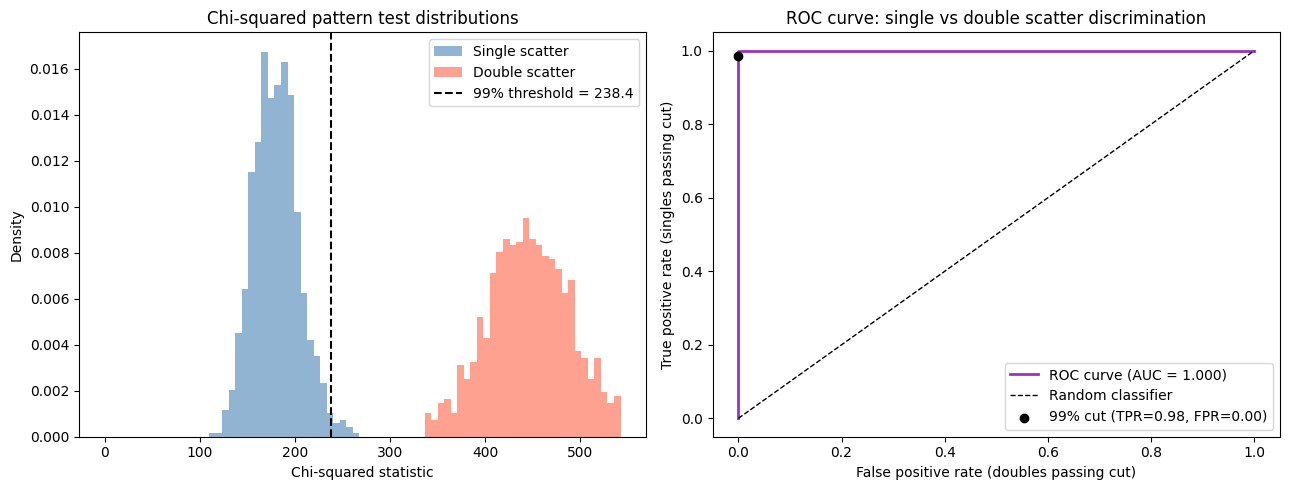

In [7]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def chi_squared_gof(observed, expected_fractions, total_photons):
    """Chi-squared goodness-of-fit between observed PMT signals and expected LCE pattern."""
    # Scale fractional LCE to absolute PE counts for comparison with observed signal
    expected_counts = expected_fractions * total_photons

    # Mask PMTs with negligible expected signal to avoid division by zero
    mask = expected_counts > 0
    chi2_stat = np.sum(
        (observed[mask] - expected_counts[mask])**2 / expected_counts[mask]
    )

    # DOF = contributing PMTs minus 1 (total is constrained)
    dof = np.sum(mask) - 1
    p_value = stats.chi2.sf(chi2_stat, dof)
    return chi2_stat, p_value


def get_chi2_threshold(position, total_photons, num_trials=5000, quantile=0.99):
    """Build a data-driven chi-squared rejection threshold from simulated calibration throws."""
    expected_fractions = mean_response(position)[0]
    chi2_values = []

    for _ in range(num_trials):
        signal = simulate_signal(position, photons=total_photons)[0]
        chi2_stat, _ = chi_squared_gof(signal, expected_fractions, signal.sum())
        chi2_values.append(chi2_stat)

    return np.quantile(chi2_values, quantile)


def classify_event(signal, position, total_photons, threshold):
    """Classify event as single scatter (pass) or outlier (reject) via chi-squared pattern test."""
    expected_fractions = mean_response(position)[0]
    chi2_stat, _ = chi_squared_gof(signal, expected_fractions, total_photons)
    return chi2_stat, chi2_stat <= threshold


def run_classification_trial(
    single_position=np.array([[0, 0]]),
    double_positions=np.array([[0, 0], [10, 10]]),
    photons=10_000,
    num_trials=1000,
    quantile=0.99
):
    """Simulate single and double scatter events and return chi-squared statistics for ROC analysis."""
    print("Building chi-squared threshold from calibration throws...")
    threshold = get_chi2_threshold(single_position, photons, quantile=quantile)
    print(f"  Chi-squared threshold at {quantile*100:.0f}th percentile: {threshold:.2f}")

    single_chi2s, double_chi2s = [], []

    for _ in range(num_trials):
        # Single scatter: one vertex, clean LCE pattern
        single_signal = simulate_signal(single_position, photons=photons)[0]
        chi2_stat, _ = classify_event(single_signal, single_position, single_signal.sum(), threshold)
        single_chi2s.append(chi2_stat)

        # Double scatter: two vertices, photons split evenly, distorted LCE pattern
        double_signal = simulate_signal(double_positions, photons=photons // 2).sum(axis=0)
        chi2_stat, _ = classify_event(double_signal, single_position, double_signal.sum(), threshold)
        double_chi2s.append(chi2_stat)

    return np.array(single_chi2s), np.array(double_chi2s), threshold


def plot_results(single_chi2s, double_chi2s, threshold):
    """Plot chi-squared distributions and ROC curve for single vs double scatter classification."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Chi-squared distributions with threshold marker
    ax = axes[0]
    bins = np.linspace(0, np.percentile(np.concatenate([single_chi2s, double_chi2s]), 99), 80)
    ax.hist(single_chi2s, bins=bins, alpha=0.6, label='Single scatter', color='steelblue', density=True)
    ax.hist(double_chi2s, bins=bins, alpha=0.6, label='Double scatter', color='tomato', density=True)
    ax.axvline(threshold, color='black', linestyle='--', label=f'99% threshold = {threshold:.1f}')
    ax.set_xlabel('Chi-squared statistic')
    ax.set_ylabel('Density')
    ax.set_title('Chi-squared pattern test distributions')
    ax.legend()

    # ROC curve — negate chi2 so that low chi2 (single-scatter-like) scores highly
    ax = axes[1]
    labels = np.concatenate([np.ones(len(single_chi2s)), np.zeros(len(double_chi2s))])
    scores  = np.concatenate([-single_chi2s, -double_chi2s])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='darkorchid', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

    # Mark operating point at the 99% threshold
    op_tpr = np.mean(single_chi2s <= threshold)
    op_fpr = np.mean(double_chi2s <= threshold)
    ax.scatter(op_fpr, op_tpr, color='black', zorder=5,
               label=f'99% cut (TPR={op_tpr:.2f}, FPR={op_fpr:.2f})')

    ax.set_xlabel('False positive rate (doubles passing cut)')
    ax.set_ylabel('True positive rate (singles passing cut)')
    ax.set_title('ROC curve: single vs double scatter discrimination')
    ax.legend()

    plt.tight_layout()
    plt.show()


# Run analysis
single_chi2s, double_chi2s, threshold = run_classification_trial(
    single_position  = np.array([[0, 0]]),
    double_positions = np.array([[0, 0], [0, 3]]),
    photons    = 10_000,
    num_trials = 1000,
    quantile   = 0.99
)
plot_results(single_chi2s, double_chi2s, threshold)

In [8]:
#Running analysis for different separation distances and photon counts and calculating AUC
#and plotting results on a contour plot of AUC vs separation distance and photon count

Separations=np.array([0, 0.5, 1, 1.5, 2, 3, 4, 5, 7.5, 10])
Photon_counts=np.array([100, 500, 1000, 5000, 10000, 50000])

def AUC_calculation(separations, photon_counts):
    AUC_results = np.zeros((len(separations), len(photon_counts)))

    for i, sep in enumerate(separations):
        for j, photons in enumerate(photon_counts):
            print(f"Running trial for separation {sep} cm and {photons} photons...")
            single_chi2s, double_chi2s, threshold = run_classification_trial(
                single_position  = np.array([[0, 0]]),
                double_positions = np.array([[0, 0], [0, sep]]),
                photons    = photons,
                num_trials = 1000,
                quantile   = 0.99
            )
            labels = np.concatenate([np.ones(len(single_chi2s)), np.zeros(len(double_chi2s))])
            scores  = np.concatenate([-single_chi2s, -double_chi2s])
            fpr, tpr, _ = roc_curve(labels, scores)
            AUC_results[i, j] = auc(fpr, tpr)

    return AUC_results

#plotting results
AUC_results = AUC_calculation(Separations, Photon_counts)
plt.figure(figsize=(10, 6))
plt.imshow(Photon_counts, Separations, AUC_results, levels=20, cmap='viridis')
plt.colorbar(label='AUC')
plt.xscale('log')
plt.xlabel('Photon count')
plt.ylabel('Separation distance (cm)')
plt.title('AUC for single vs double scatter classification')
plt.show()

Running trial for separation 0.0 cm and 100 photons...
Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 306.15
Running trial for separation 0.0 cm and 500 photons...
Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 260.44
Running trial for separation 0.0 cm and 1000 photons...
Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 248.76
Running trial for separation 0.0 cm and 5000 photons...
Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 240.95
Running trial for separation 0.0 cm and 10000 photons...
Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 236.98
Running trial for separation 0.0 cm and 50000 photons...
Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 236.76
Running tr

TypeError: imshow() got multiple values for argument 'cmap'

<Figure size 1000x600 with 0 Axes>

In [11]:
import numpy as np
from scipy import stats, optimize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def log_likelihood(signal, position, total_photons):
    """
    Log-likelihood of observing the PMT signal given a single scatter at position.
    Models observed PE counts as Poisson-distributed around the expected LCE pattern.
    """
    expected_counts = mean_response(position)[0] * total_photons
    # Poisson log-likelihood: sum of (k*log(lambda) - lambda) over PMTs
    mask = expected_counts > 0
    return np.sum(
        signal[mask] * np.log(expected_counts[mask]) - expected_counts[mask]
    )


def fit_single_scatter(signal, initial_position, total_photons):
    """
    Find the position that maximises the likelihood under the single scatter hypothesis.
    Returns the best-fit position and the maximum log-likelihood value.
    """
    def neg_log_likelihood(pos):
        return -log_likelihood(signal, pos.reshape(1, 2), total_photons)

    result = optimize.minimize(
        neg_log_likelihood,
        x0=initial_position.flatten(),
        method='Nelder-Mead',
        options={'xatol': 0.0001, 'fatol': 0.0001}
    )
    return result.x, -result.fun


def fit_double_scatter(signal, initial_positions, total_photons):
    """
    Find the two positions and light fraction that maximise the likelihood
    under the double scatter hypothesis.
    The parameter vector is [x1, y1, x2, y2, f] where f is the fraction
    of light from the first scatter.
    """
    def neg_log_likelihood(params):
        pos1  = params[:2].reshape(1, 2)
        pos2  = params[2:4].reshape(1, 2)
        # f is the fraction of photons from scatter 1; constrained to [0.05, 0.95]
        f     = np.clip(params[4], 0.05, 0.95)
        # Combined expected pattern: weighted sum of two LCE maps
        lce1  = mean_response(pos1)[0]
        lce2  = mean_response(pos2)[0]
        combined = f * lce1 + (1 - f) * lce2
        expected_counts = combined * total_photons
        mask  = expected_counts > 0
        ll    = np.sum(signal[mask] * np.log(expected_counts[mask]) - expected_counts[mask])
        return -ll

    x0 = np.append(initial_positions.flatten(), 0.5)  # start with equal light split
    result = optimize.minimize(
        neg_log_likelihood, x0=x0,
        method='Nelder-Mead',
        options={'xatol': 0.0001, 'fatol': 0.0001}
    )
    return result.x[:4].reshape(2, 2), -result.fun


def profile_likelihood_ratio(signal, initial_position, total_photons):
    """
    Compute the profile likelihood ratio test statistic:

        lambda = -2 * log[ L(single scatter) / L(double scatter) ]

    A large positive value means the double scatter hypothesis fits much
    better — the event is likely a double scatter and should be rejected.
    Under the single scatter null hypothesis, lambda is asymptotically
    chi-squared distributed with degrees of freedom equal to the difference
    in free parameters (5 - 2 = 3).
    """
    # Maximise likelihood under each hypothesis
    _, ll_single = fit_single_scatter(signal, initial_position, total_photons)

    # Initialise double scatter fit with a small offset from the single scatter position
    double_init = np.vstack([initial_position, initial_position + np.array([[5, 5]])])
    _, ll_double = fit_double_scatter(signal, double_init, total_photons)

    # Test statistic: negative means single scatter fits better, positive means double fits better
    return -2 * (ll_single - ll_double)


def get_plr_threshold(position, total_photons, num_trials=2000, quantile=0.99):
    """Build a data-driven PLR threshold from simulated single scatter calibration throws."""
    print("Building PLR threshold from calibration throws...")
    plr_values = []

    for i in range(num_trials):
        if i % 200 == 0:
            print(f"  Calibration throw {i}/{num_trials}")
        signal = simulate_signal(position, photons=total_photons)[0]
        plr    = profile_likelihood_ratio(signal, position, signal.sum())
        plr_values.append(plr)

    threshold = np.quantile(plr_values, quantile)
    print(f"  PLR threshold at {quantile*100:.0f}th percentile: {threshold:.2f}")
    return threshold


def run_plr_trial(
    single_position  = np.array([[0, 0]]),
    double_positions = np.array([[0, 0], [10, 10]]),
    photons    = 10_000,
    num_trials = 500,
    quantile   = 0.99
):
    """Simulate single and double scatter events and return PLR statistics."""
    threshold = get_plr_threshold(single_position, photons, quantile=quantile)

    single_plrs, double_plrs = [], []

    for i in range(num_trials):
        if i % 100 == 0:
            print(f"  Trial {i}/{num_trials}")

        # Single scatter: expect PLR near zero (both hypotheses fit similarly)
        single_signal = simulate_signal(single_position, photons=photons)[0]
        single_plrs.append(profile_likelihood_ratio(
            single_signal, single_position, single_signal.sum()
        ))

        # Double scatter: expect large PLR (double hypothesis fits much better)
        double_signal = simulate_signal(double_positions, photons=photons // 2).sum(axis=0)
        double_plrs.append(profile_likelihood_ratio(
            double_signal, single_position, double_signal.sum()
        ))

    return np.array(single_plrs), np.array(double_plrs), threshold


def plot_plr_results(single_plrs, double_plrs, threshold):
    """Plot PLR distributions and ROC curve."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # PLR distributions
    ax   = axes[0]
    clip = np.percentile(np.concatenate([single_plrs, double_plrs]), 99)
    bins = np.linspace(0, clip, 80)
    ax.hist(single_plrs, bins=bins, alpha=0.6, label='Single scatter', color='steelblue', density=True)
    ax.hist(double_plrs, bins=bins, alpha=0.6, label='Double scatter', color='tomato',   density=True)
    ax.axvline(threshold, color='black', linestyle='--', label=f'99% threshold = {threshold:.1f}')
    ax.set_xlabel('Profile likelihood ratio $-2\,\Delta\ln L$')
    ax.set_ylabel('Density')
    ax.set_title('PLR test distributions')
    ax.legend()

    # ROC curve — negate PLR so that low PLR (single-scatter-like) scores highly
    ax     = axes[1]
    labels = np.concatenate([np.ones(len(single_plrs)), np.zeros(len(double_plrs))])
    scores = np.concatenate([-single_plrs, -double_plrs])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='darkorchid', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

    op_tpr = np.mean(single_plrs <= threshold)
    op_fpr = np.mean(double_plrs <= threshold)
    ax.scatter(op_fpr, op_tpr, color='black', zorder=5,
               label=f'99% cut (TPR={op_tpr:.2f}, FPR={op_fpr:.2f})')

    ax.set_xlabel('False positive rate (doubles passing cut)')
    ax.set_ylabel('True positive rate (singles passing cut)')
    ax.set_title('ROC curve: single vs double scatter discrimination')
    ax.legend()

    plt.tight_layout()
    plt.show()


# Run analysis
#single_plrs, double_plrs, threshold = run_plr_trial(
    single_position  = np.array([[0, 0]]),
    double_positions = np.array([[0, 0], [0, 1.2]]),
    photons    = 10_000,
    num_trials = 500,
    quantile   = 0.99
#)
#plot_plr_results(single_plrs, double_plrs, threshold)

<>:148: SyntaxWarning: invalid escape sequence '\,'
<>:148: SyntaxWarning: invalid escape sequence '\,'
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_19968\2946554766.py:148: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('Profile likelihood ratio $-2\,\Delta\ln L$')


Running PLR trial: separation=0.0 cm, photons=5000
Building PLR threshold from calibration throws...
  Calibration throw 0/2000
  Calibration throw 200/2000
  Calibration throw 400/2000
  Calibration throw 600/2000
  Calibration throw 800/2000
  Calibration throw 1000/2000
  Calibration throw 1200/2000
  Calibration throw 1400/2000
  Calibration throw 1600/2000
  Calibration throw 1800/2000
  PLR threshold at 99th percentile: 13.37
  Trial 0/500
  Trial 100/500
  Trial 200/500
  Trial 300/500
  Trial 400/500
Running PLR trial: separation=0.0 cm, photons=10000
Building PLR threshold from calibration throws...
  Calibration throw 0/2000
  Calibration throw 200/2000
  Calibration throw 400/2000
  Calibration throw 600/2000
  Calibration throw 800/2000
  Calibration throw 1000/2000
  Calibration throw 1200/2000
  Calibration throw 1400/2000
  Calibration throw 1600/2000
  Calibration throw 1800/2000
  PLR threshold at 99th percentile: 12.09
  Trial 0/500
  Trial 100/500
  Trial 200/500
  T

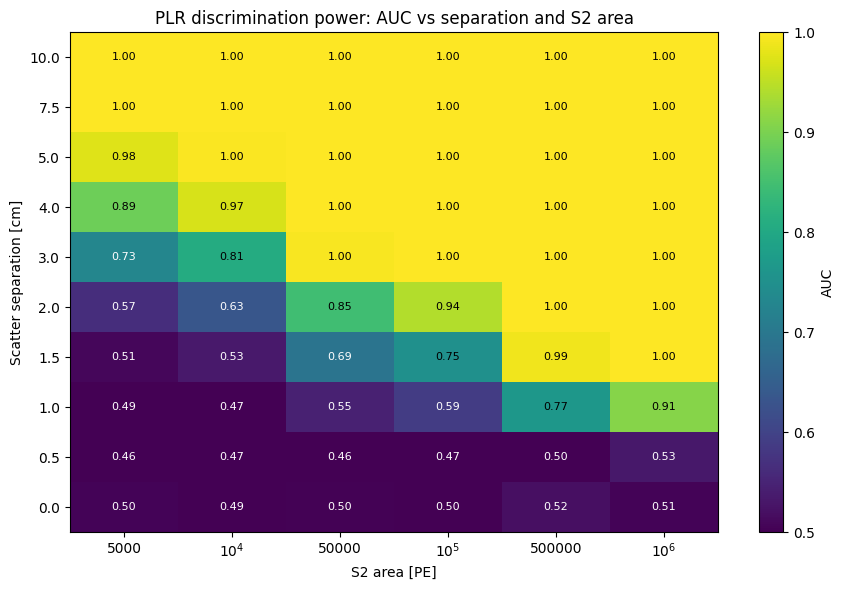

In [12]:
Separations   = np.array([0, 0.5, 1, 1.5, 2, 3, 4, 5, 7.5, 10])
Photon_counts = np.array([5000, 10000, 50000, 100000, 500000, 1_000_000])

def AUC_calculation(separations, photon_counts, num_trials=500, quantile=0.99):
    """
    Compute AUC of the PLR test across a grid of separation distances and photon counts.
    Separations are along the y-axis from (0,0).
    """
    AUC_results = np.zeros((len(separations), len(photon_counts)))

    for i, sep in enumerate(separations):
        for j, photons in enumerate(photon_counts):
            print(f"Running PLR trial: separation={sep} cm, photons={photons}")

            single_plrs, double_plrs, threshold = run_plr_trial(
                single_position  = np.array([[0, 0]]),
                double_positions = np.array([[0, 0], [0, sep]]),
                photons    = photons,
                num_trials = num_trials,
                quantile   = quantile
            )

            # Negate PLR so that low values (single-scatter-like) score highly
            labels = np.concatenate([np.ones(len(single_plrs)), np.zeros(len(double_plrs))])
            scores = np.concatenate([-single_plrs, -double_plrs])
            fpr, tpr, _ = roc_curve(labels, scores)
            AUC_results[i, j] = auc(fpr, tpr)

    return AUC_results


def plot_auc_heatmap(AUC_results, separations, photon_counts):
    """Heatmap of AUC as a function of scatter separation and S2 area."""
    fig, ax = plt.subplots(figsize=(9, 6))

    im = ax.imshow(AUC_results, aspect='auto', cmap='viridis', 
                   vmin=0.5, vmax=1.0, origin='lower')
    plt.colorbar(im, ax=ax, label='AUC')

    # Annotate each cell with its AUC value
    for i in range(len(separations)):
        for j in range(len(photon_counts)):
            ax.text(j, i, f'{AUC_results[i, j]:.2f}',
                    ha='center', va='center',
                    color='white' if AUC_results[i, j] < 0.75 else 'black',
                    fontsize=8)

    ax.set_xticks(range(len(photon_counts)))
    ax.set_xticklabels([f'$10^{{{int(np.log10(p))}}}$' if np.log10(p) % 1 == 0
                        else str(p) for p in photon_counts])
    ax.set_yticks(range(len(separations)))
    ax.set_yticklabels(separations)
    ax.set_xlabel('S2 area [PE]')
    ax.set_ylabel('Scatter separation [cm]')
    ax.set_title('PLR discrimination power: AUC vs separation and S2 area')

    plt.tight_layout()
    plt.show()


# Run and plot
AUC_results = AUC_calculation(Separations, Photon_counts)
plot_auc_heatmap(AUC_results, Separations, Photon_counts)